# Sales Data Analysis

## Project Overview

This project analyzes sales data to identify patterns in product demand, revenue, customer ordering times, monthly sales, and city-wise performance.

The analysis uses Python, Pandas, NumPy, Matplotlib, and Seaborn to clean, analyze, and visualize the dataset.

## Business Questions

The project aims to answer the following questions:

1. Which products are sold the most?
2. Which products generate the highest revenue?
3. Which month has the highest sales?
4. Which city generates the highest sales?
5. What time of day receives the most orders?
6. Is there a relationship between quantity sold and revenue?
7. Which are the top 5 products by revenue?

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Purpose

The libraries are used for data manipulation, numerical operations, and data visualization.

- **Pandas** – data cleaning and analysis
- **NumPy** – numerical operations
- **Matplotlib** – creating visualizations
- **Seaborn** – statistical visualization

## 2. Load Dataset

In [2]:
df= pd.read_csv("../data/Sales Data.csv")
df.head()

,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0
1,1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7
2,2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18
3,3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15
4,4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12


### Purpose

The CSV file is loaded into a Pandas DataFrame called `df`.

A DataFrame is a table-like structure containing rows and columns that can be easily analyzed using Pandas.

## 3. Data Understanding

In [3]:
df.shape

(185950, 11)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        185950 non-null  int64  
 1   Order ID          185950 non-null  int64  
 2   Product           185950 non-null  object 
 3   Quantity Ordered  185950 non-null  int64  
 4   Price Each        185950 non-null  float64
 5   Order Date        185950 non-null  object 
 6   Purchase Address  185950 non-null  object 
 7   Month             185950 non-null  int64  
 8   Sales             185950 non-null  float64
 9   City              185950 non-null  object 
 10  Hour              185950 non-null  int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 15.6+ MB


### Purpose

These functions help us understand the dataset before performing analysis.

- `shape` → shows number of rows and columns
- `info()` → shows column names, data types, and non-null values

## 4. Data Cleaning

In [5]:
df.columns

Index(['Unnamed: 0', 'Order ID', 'Product', 'Quantity Ordered', 'Price Each',
       'Order Date', 'Purchase Address', 'Month', 'Sales', 'City', 'Hour'],
      dtype='object')

In [6]:
df.isnull().sum() 

Unnamed: 0          0
Order ID            0
Product             0
Quantity Ordered    0
Price Each          0
Order Date          0
Purchase Address    0
Month               0
Sales               0
City                0
Hour                0
dtype: int64

In [7]:
df["Unnamed: 0"].head(10) 

0    0
1    1
2    2
3    3
4    4
5    5
6    6
7    7
8    8
9    9
Name: Unnamed: 0, dtype: int64

In [8]:
df= df.drop(columns=["Unnamed: 0"]) 

In [9]:
df["Order ID"].head(10) 

0    295665
1    295666
2    295667
3    295668
4    295669
5    295670
6    295671
7    295672
8    295673
9    295674
Name: Order ID, dtype: int64

In [10]:
df=df.drop_duplicates() 

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185686 entries, 0 to 185949
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Order ID          185686 non-null  int64  
 1   Product           185686 non-null  object 
 2   Quantity Ordered  185686 non-null  int64  
 3   Price Each        185686 non-null  float64
 4   Order Date        185686 non-null  object 
 5   Purchase Address  185686 non-null  object 
 6   Month             185686 non-null  int64  
 7   Sales             185686 non-null  float64
 8   City              185686 non-null  object 
 9   Hour              185686 non-null  int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 15.6+ MB


In [13]:
df["Order Date"]= pd.to_datetime(df["Order Date"])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185686 entries, 0 to 185949
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order ID          185686 non-null  int64         
 1   Product           185686 non-null  object        
 2   Quantity Ordered  185686 non-null  int64         
 3   Price Each        185686 non-null  float64       
 4   Order Date        185686 non-null  datetime64[ns]
 5   Purchase Address  185686 non-null  object        
 6   Month             185686 non-null  int64         
 7   Sales             185686 non-null  float64       
 8   City              185686 non-null  object        
 9   Hour              185686 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 15.6+ MB


In [54]:
df = df.reset_index(drop=True)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185686 entries, 0 to 185685
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order ID          185686 non-null  int64         
 1   Product           185686 non-null  object        
 2   Quantity Ordered  185686 non-null  int64         
 3   Price Each        185686 non-null  float64       
 4   Order Date        185686 non-null  datetime64[ns]
 5   Purchase Address  185686 non-null  object        
 6   Month             185686 non-null  int64         
 7   Sales             185686 non-null  float64       
 8   City              185686 non-null  object        
 9   Hour              185686 non-null  int64         
 10  year              185686 non-null  int32         
 11  Day               185686 non-null  int32         
 12  Day of Week       185686 non-null  object        
dtypes: datetime64[ns](1), float64(2), int32(2), int64(4), objec

### Cleaning Operations

The dataset was cleaned by:

- Removing the unnecessary `Unnamed: 0` column.
- Checking for missing values.
- Identifying and removing duplicate records.
- Converting `Order Date` from text format to datetime format.

After cleaning, the dataset contains **185,686 records**.

## 5. Feature Engineering

In [16]:
df["year"]=df["Order Date"].dt.year

In [17]:
df["year"].value_counts()

year
2019    185652
2020        34
Name: count, dtype: int64

In [18]:
df["Day"]=df["Order Date"].dt.day

In [19]:
df["Day of Week"]= df["Order Date"].dt.day_name()

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185686 entries, 0 to 185949
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order ID          185686 non-null  int64         
 1   Product           185686 non-null  object        
 2   Quantity Ordered  185686 non-null  int64         
 3   Price Each        185686 non-null  float64       
 4   Order Date        185686 non-null  datetime64[ns]
 5   Purchase Address  185686 non-null  object        
 6   Month             185686 non-null  int64         
 7   Sales             185686 non-null  float64       
 8   City              185686 non-null  object        
 9   Hour              185686 non-null  int64         
 10  year              185686 non-null  int32         
 11  Day               185686 non-null  int32         
 12  Day of Week       185686 non-null  object        
dtypes: datetime64[ns](1), float64(2), int32(2), int64(4), object(4)


In [21]:
df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour,year,Day,Day of Week
0,295665,Macbook Pro Laptop,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0,2019,30,Monday
1,295666,LG Washing Machine,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7,2019,29,Sunday
2,295667,USB-C Charging Cable,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,New York City,18,2019,12,Thursday
3,295668,27in FHD Monitor,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15,2019,22,Sunday
4,295669,USB-C Charging Cable,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12,2019,18,Wednesday


### Purpose

New features were extracted from the order date to make the dataset easier to analyze.

- `Year` → identifies the year of the order
- `Day` → identifies the day of the month
- `Day of Week` → identifies the weekday

# 6. Sales Analysis

## 6.1 Quantity Sold by Product

In [22]:
product_quantity= df.groupby("Product")["Quantity Ordered"].sum()

In [23]:
product_quantity= product_quantity.sort_values(ascending = False)

In [24]:
product_quantity

Product
AAA Batteries (4-pack)        30986
AA Batteries (4-pack)         27615
USB-C Charging Cable          23931
Lightning Charging Cable      23169
Wired Headphones              20524
Apple Airpods Headphones      15637
Bose SoundSport Headphones    13430
27in FHD Monitor               7541
iPhone                         6847
27in 4K Gaming Monitor         6239
34in Ultrawide Monitor         6192
Google Phone                   5529
Flatscreen TV                  4813
Macbook Pro Laptop             4725
ThinkPad Laptop                4128
20in Monitor                   4126
Vareebadd Phone                2068
LG Washing Machine              666
LG Dryer                        646
Name: Quantity Ordered, dtype: int64

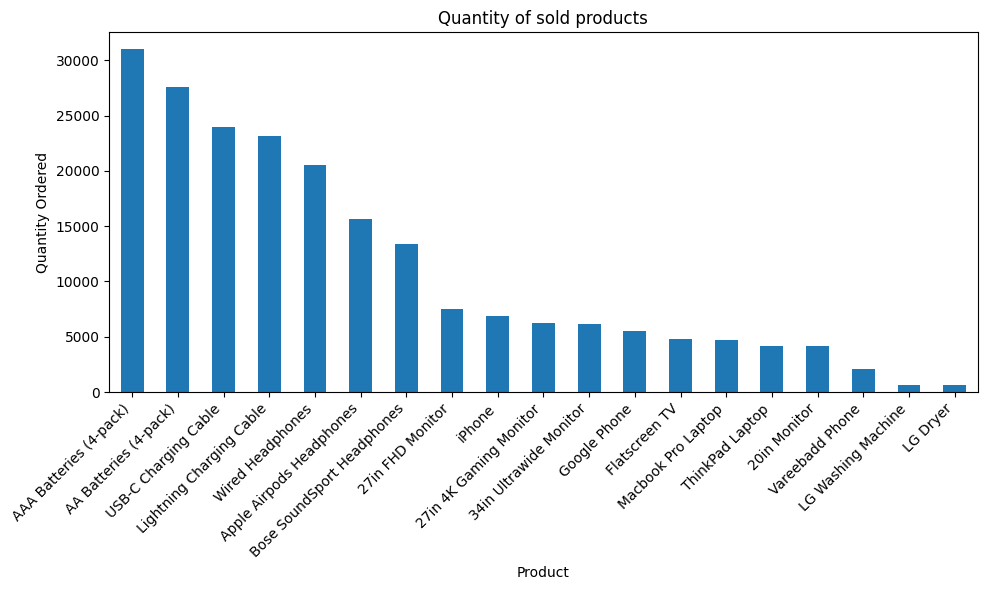

In [25]:
plt.figure(figsize=(10,6))
product_quantity.plot(kind="bar")
plt.title("Quantity of sold products")
plt.xlabel("Product")
plt.ylabel("Quantity Ordered")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../visualization/quantity_of_sold_products.png")
plt.show()

### Insight

AAA Batteries (4-pack) have the highest quantity sold, followed by AA Batteries (4-pack). Low-priced accessories and batteries have substantially higher sales volumes than expensive electronic products.

## 6.2 Revenue by Product

In [26]:
product_sales=df.groupby("Product")["Sales"].sum()
product_sales=product_sales.sort_values(ascending=False)

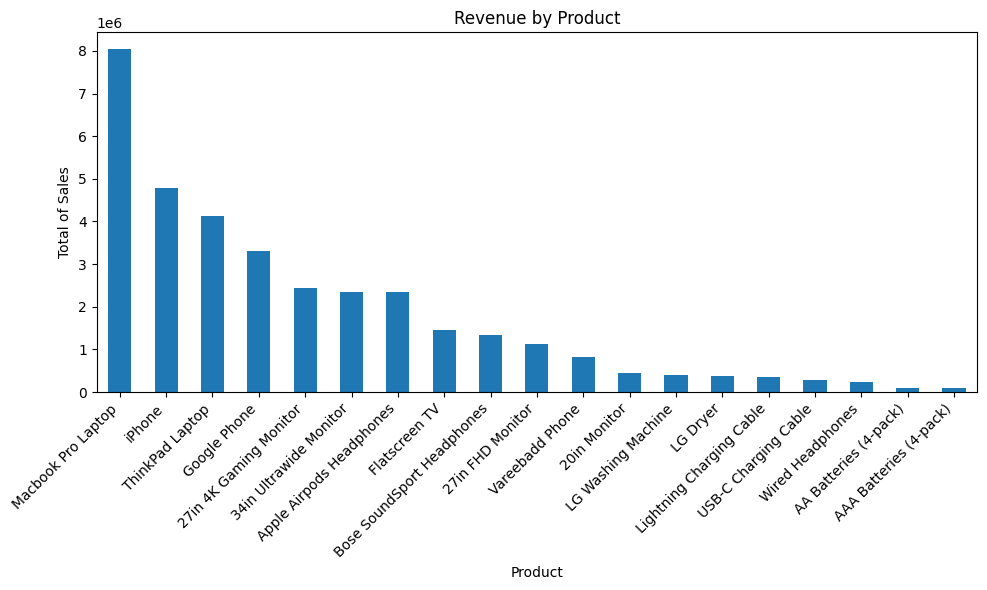

In [27]:
plt.figure(figsize=(10,6))
product_sales.plot(kind="bar")
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Total of Sales")
plt.xticks(rotation=45, ha="right")
plt.savefig("../visualization/Revenue_of_product.png")
plt.tight_layout()
plt.show()

### Insight

MacBook Pro Laptop generates the highest revenue, followed by iPhone and ThinkPad Laptop. High-priced products generate greater revenue even when their sales quantities are lower.

## 6.3 Monthly Sales Analysis

This analysis examines how total sales change across different months of the year.

It helps identify periods of high and low sales activity.

In [28]:
monthly_sales= df.groupby("Month")["Sales"].sum()
monthly_sales=monthly_sales.sort_index()
monthly_sales

Month
1     1821413.16
2     2200078.08
3     2804973.35
4     3389217.98
5     3150616.23
6     2576280.15
7     2646461.32
8     2241083.37
9     2094465.69
10    3734777.86
11    3197875.05
12    4608295.70
Name: Sales, dtype: float64

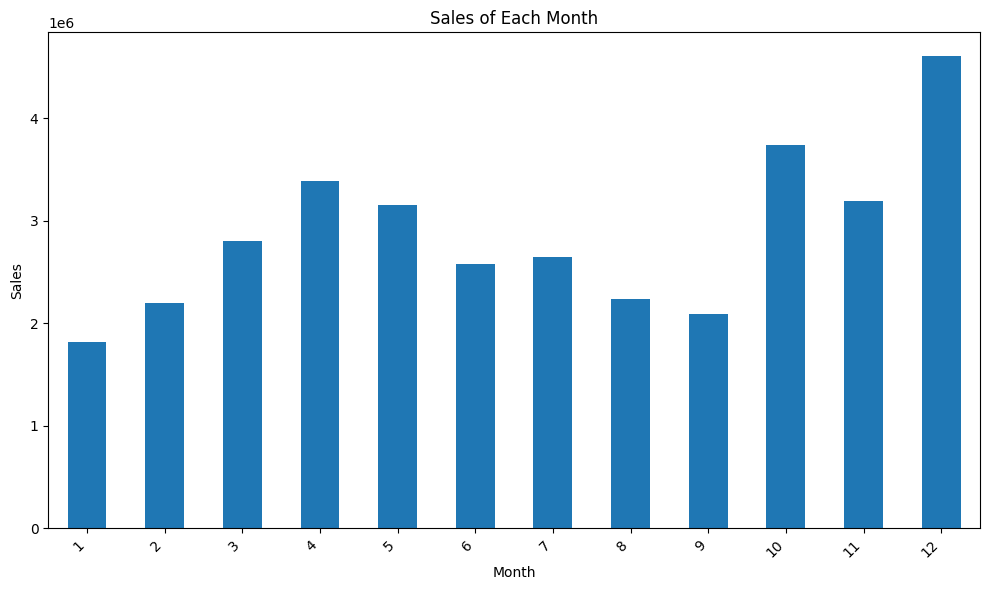

In [29]:
plt.figure(figsize=(10,6))
monthly_sales.plot(kind="bar")
plt.title("Sales of Each Month")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../visualization/monthly_sales.png")
plt.show()

### Insight

December recorded the highest sales among the months, while January recorded the lowest sales. Overall, sales show stronger activity toward the end of the year.

## 6.4 Sales by City

This analysis compares total sales across different cities.

It helps identify geographical areas with higher and lower sales activity.

In [30]:
city_sales= df.groupby("City")["Sales"].sum()
city_sales=city_sales.sort_values(ascending=False)
city_sales

City
San Francisco    8254743.55
Los Angeles      5448304.28
New York City    4661867.14
Boston           3658627.65
Atlanta          2794199.07
Dallas           2765373.96
Seattle          2745046.02
Portland         2319331.94
Austin           1818044.33
Name: Sales, dtype: float64

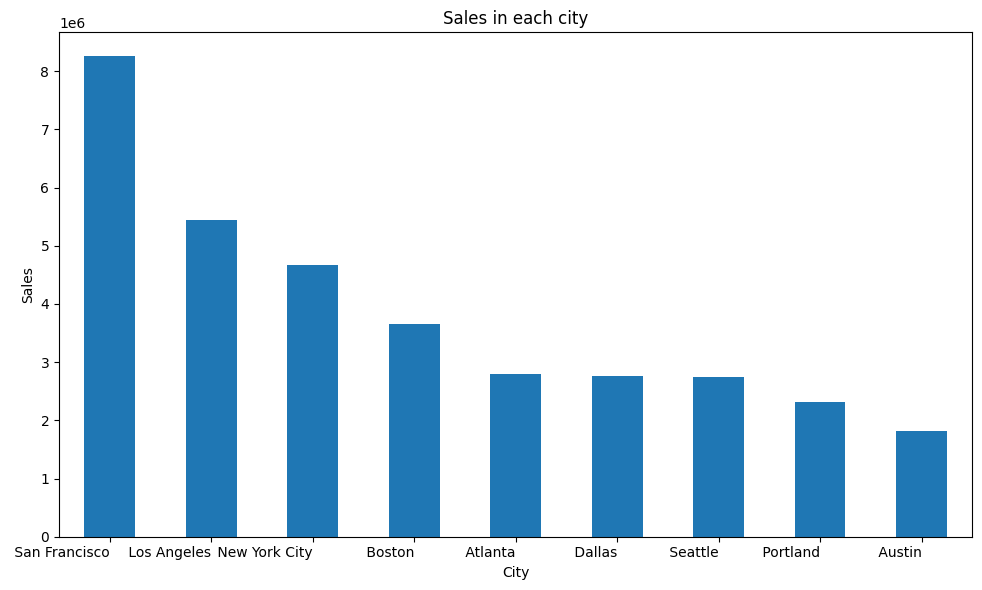

In [34]:
plt.figure(figsize=(10,6))
city_sales.plot(kind="bar")
plt.title("Sales in each city")
plt.xlabel("City")
plt.ylabel("Sales")
plt.xticks(rotation=0, ha="right")
plt.tight_layout()
plt.savefig("../visualization/city_sales.png")
plt.show()

### Insight

San Francisco recorded the highest sales among the cities in the dataset, while Austin recorded the lowest sales.

## 6.5 Orders by Hour

This analysis examines the number of orders placed during each hour of the day.

It helps identify the time periods when customer ordering activity is highest.

In [35]:
hourly_orders = df.groupby("Hour")["Order ID"].count()
hourly_orders

Hour
0      3902
1      2347
2      1242
3       830
4       852
5      1320
6      2481
7      4002
8      6252
9      8740
10    10929
11    12392
12    12573
13    12115
14    10965
15    10159
16    10359
17    10884
18    12263
19    12886
20    12218
21    10905
22     8808
23     6262
Name: Order ID, dtype: int64

In [38]:
hourly_orders.idxmax()

np.int64(19)

In [39]:
hourly_orders.max()

np.int64(12886)

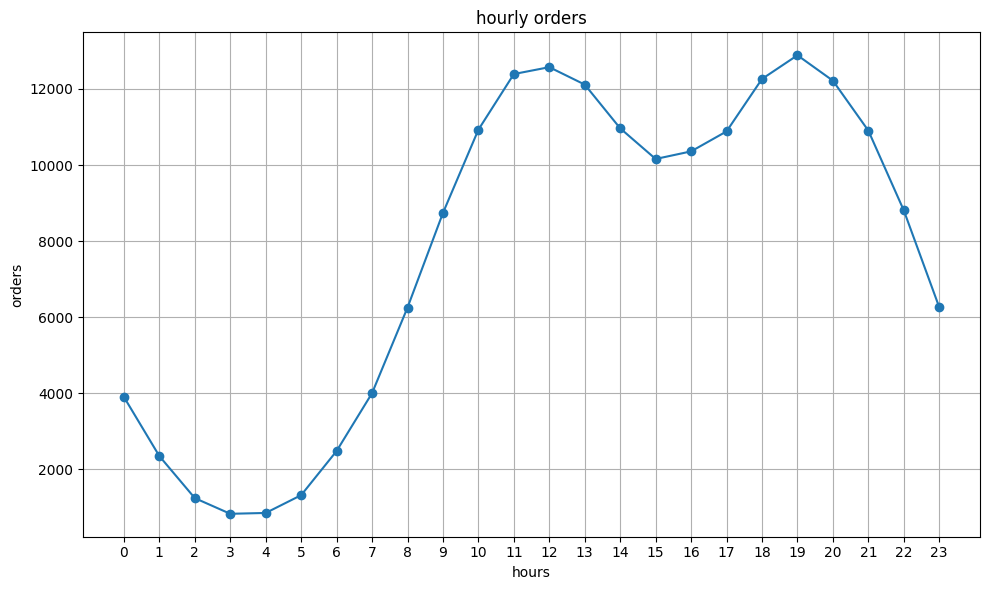

In [40]:
plt.figure(figsize=(10,6))
hourly_orders.plot(kind="line", marker="o")
plt.title("hourly orders")
plt.xlabel("hours")
plt.ylabel("orders")
plt.xticks(range(0,24))
plt.grid(True)
plt.tight_layout()
plt.savefig("../visualization/hourly_orders.png")
plt.show()

### Insight

The highest number of orders was recorded at 7 PM (19:00), with 12,886 orders. This indicates that customer ordering activity is highest during the evening.

## 6.6 Quantity Sold vs Revenue

This analysis examines the relationship between the total quantity sold and the total revenue generated by each product.

A scatter plot is used because both variables are numerical and we want to observe their relationship.

In [43]:
product_analysis=df.groupby("Product").agg({
    "Quantity Ordered":"sum",
    "Sales":"sum"
})
product_analysis=product_analysis.sort_values(
    by="Sales",
    ascending=False
)
product_analysis

,Quantity Ordered,Sales
Product,,
Macbook Pro Laptop,4725,8032500.00
iPhone,6847,4792900.00
ThinkPad Laptop,4128,4127958.72
Google Phone,5529,3317400.00
27in 4K Gaming Monitor,6239,2433147.61
34in Ultrawide Monitor,6192,2352898.08
Apple Airpods Headphones,15637,2345550.00
Flatscreen TV,4813,1443900.00
Bose SoundSport Headphones,13430,1342865.70


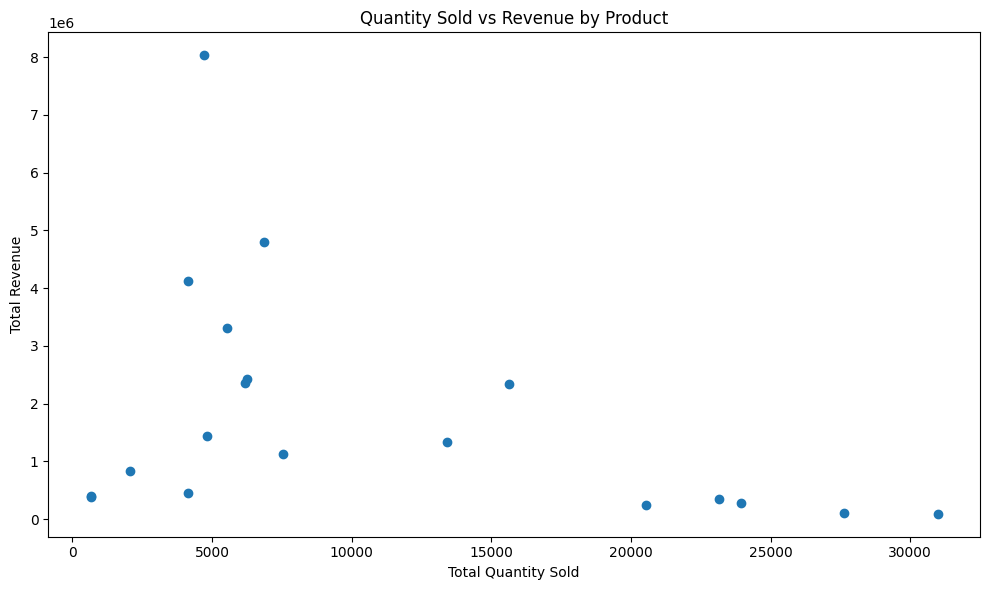

In [44]:
plt.figure(figsize=(10,6))

plt.scatter(
    product_analysis["Quantity Ordered"],
    product_analysis["Sales"]
)

plt.title("Quantity Sold vs Revenue by Product")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.savefig("../visualization/quantity_vs_revenue.png")
plt.show()

### Insight

The analysis shows that sales quantity and revenue are related, but products with high quantities sold do not necessarily generate the highest revenue. Product price also has a major effect on total revenue.

## 6.7 Top 5 Products by Revenue

This analysis identifies the five products that generated the highest total revenue.

Focusing on the top products helps us understand which products contribute significantly to overall sales revenue.

In [46]:
top_5_products=product_sales.head(5)
top_5_products

Product
Macbook Pro Laptop        8032500.00
iPhone                    4792900.00
ThinkPad Laptop           4127958.72
Google Phone              3317400.00
27in 4K Gaming Monitor    2433147.61
Name: Sales, dtype: float64

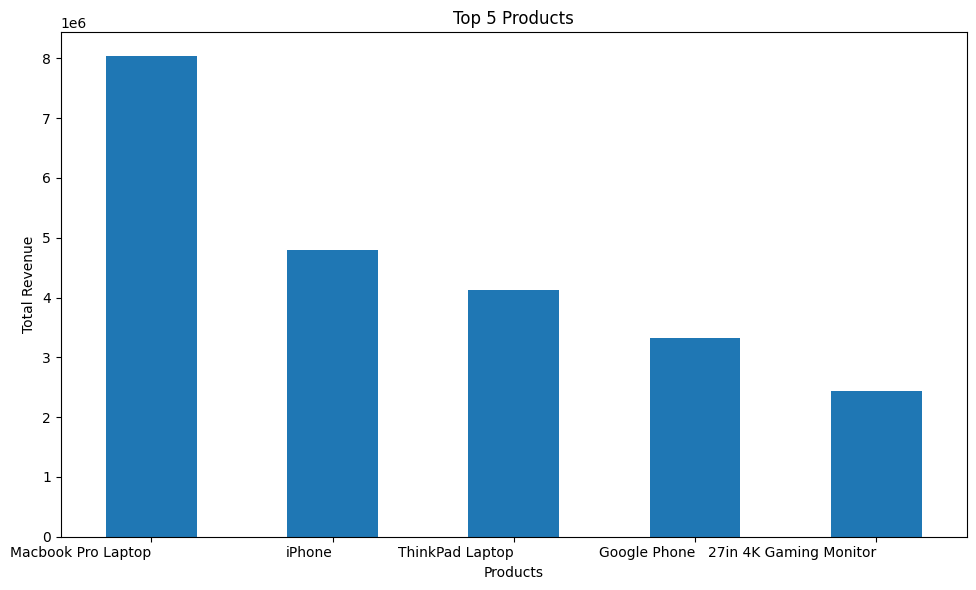

In [52]:
plt.figure(figsize=(10,6))
top_5_products.plot(kind="bar")
plt.title("Top 5 Products")
plt.xlabel("Products")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0, ha="right")
plt.tight_layout()
plt.savefig("../visualization/top_5_products.png")
plt.show()

### Insight

The top five products by revenue are MacBook Pro Laptop, iPhone, ThinkPad Laptop, Google Phone, and 27in 4K Gaming Monitor. These products contribute significantly to total revenue because of their relatively high selling prices.

# 7. Business Insights

The analysis of the sales dataset revealed several important business patterns:

1. **High sales volume does not always mean high revenue.** Batteries and charging cables are sold in large quantities, while expensive products such as laptops and smartphones generate higher revenue.

2. **December has the highest sales.** This indicates stronger purchasing activity toward the end of the year.

3. **San Francisco has the highest sales among the analyzed cities.** This shows that sales performance varies across geographical locations.

4. **7 PM is the busiest ordering hour.** The dataset recorded 12,886 orders at 7 PM, indicating strong evening customer activity.

5. **Product price affects revenue significantly.** Products with lower quantities sold can still generate high revenue when their individual selling price is higher.

6. **Top-revenue products are mainly higher-priced electronics.** These products make a significant contribution to total sales revenue.

# 8. Conclusion

This project analyzed sales data to identify patterns in product demand, revenue, monthly performance, city-wise sales, and customer ordering times.

The analysis showed that different products contribute to sales in different ways. Some products have high sales volume, while higher-priced products generate greater revenue. December recorded the highest monthly sales, San Francisco had the highest city-wise sales, and 7 PM was the busiest ordering hour.

Overall, the project demonstrates how data analysis and visualization can be used to understand customer behavior, identify sales patterns, and support data-driven business decisions.